Adaptive RAG with Llama

구글 코랩 사용 추천

In [4]:
!nvidia-smi

Sun May 17 07:18:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
!pip install langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core duckduckgo-search langchain-community chromadb langchain-ollama

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/

In [6]:
import os
from uuid import uuid4

In [54]:
unique_id = uuid4().hex[0:8]
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_PROJECT'] = f'Adaptive RAG (Using Llama) - {unique_id}'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = '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'
os.environ['TAVILY_API_KEY'] = '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'

In [8]:
unique_id

'52808105'

Ollama

In [9]:
!apt-get update
!apt-get install -y zstd

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,644 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,341 kB]
Hit:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,292 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-s

In [10]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [22]:
!ollama

Ollama 0.24.0

▸ Chat with a model
    Start an interactive chat with a model

  Launch Claude Code (not installed)
    Anthropic's coding tool with subagents

  Launch Hermes Agent (install)
    Self-improving AI agent built by Nous Research

  Launch OpenClaw (install)
    Personal AI with 100+ skills

  Launch OpenCode (not installed)
    Anomaly's open-source coding agent

  More...
    Show additional integrations


Error: run launcher menu: error running TUI: program was killed: program was interrupted


In [12]:
import subprocess
process = subprocess.Popen('ollama serve', shell=True)

LLM

In [13]:
!ollama pull llama3.2:3b-instruct-fp16

Error: unknown command "pulll" for "ollama"

Did you mean this?
	pull



In [14]:
from langchain_ollama import ChatOllama

In [24]:
local_llm = 'llama3.2:3b-instruct-fp16'
llm = ChatOllama(model=local_llm, temperature=0)
llm_json_mode = ChatOllama(model=local_llm, temperature=0, format='json')

vectorstore

Embedding

In [25]:
from langchain_community.embeddings import HuggingFaceEmbeddings

In [26]:
model_name = 'BAAI/bge-large-en-v1.5'
model_kwargs = {'device': 'cuda'}
encode_kwargs = {'normalize_embeddings': False}
hf = HuggingFaceEmbeddings(
    model_name = model_name,
    model_kwargs = model_kwargs,
    encode_kwargs = encode_kwargs
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import SKLearnVectorStore

In [28]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size = 1000, chunk_overlap=200
)
doc_splits = text_splitter.split_documents(docs_list)

vectorstore = SKLearnVectorStore.from_documents(
    documents=doc_splits,
    embedding=hf,
)

retriever = vectorstore.as_retriever(k=3)

In [29]:
import json
from langchain_core.messages import HumanMessage, SystemMessage

In [32]:
router_instructions = """ You are an expert at routing a user question to a vectorstore or web search.

The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.

Use the vectorstore for questions on these topics. For all else, and especially for current events, use web-search.

Return JSON with single key, datasource, that is 'websearch' or 'vectorstore' depending on the question."""

test_web_search = llm_json_mode.invoke(
    [SystemMessage(content=router_instructions)]
    +[
        HumanMessage(
            content='Who is favored to win the NFC Championship game in the 2024 season?'
        )
    ]
)
test_web_search_2 = llm_json_mode.invoke(
    [SystemMessage(content=router_instructions)]
    +[
        HumanMessage(
            content='What are the models released today for llama3.2?'
        )
    ]
)
test_vector_store = llm_json_mode.invoke(
    [SystemMessage(content=router_instructions)]
    + [HumanMessage(content='What are the types of agent memory?')]
)

print(
    json.loads(test_web_search.content),
    json.loads(test_web_search_2.content),
    json.loads(test_vector_store.content),
)


{'datasource': 'websearch'} {'datasource': 'websearch'} {'datasource': 'vectorstore'}


In [33]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [34]:
doc_grader_instructions = """You are a grader assessing relevance of a retrieved document to a user question.

If the documnet contains keyword(s) or semantic meaning related to the question, grade it as relevant."""

doc_grader_prompt = """Here is the retrieved document: \n\n {document} \n\n Here is the user question: \n\n {question}.

This carefully and objectively assess whether the document dontains at least some information that is erlevant to the question.

Return JSON with single key, binary_score, that is 'yes' or 'no' score to indicate whether the document contains at least some information that is relevant to the question.
"""

question = 'What is Chain of thought prompting?'
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
doc_grader_prompt_formatted = doc_grader_prompt.format(
    document=doc_txt, question = question
)
result = llm_json_mode.invoke(
    [SystemMessage(content=doc_grader_instructions)]
    +[HumanMessage(content=doc_grader_prompt_formatted)]
)
json.loads(result.content)

{'binary_score': 'yes'}

In [35]:
question

'What is Chain of thought prompting?'

In [36]:
docs[1]

Document(metadata={'id': '882d6375-bdc6-4339-be87-671fdaed979f', 'source': 'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/', 'title': "Prompt Engineering | Lil'Log", 'description': 'Prompt Engineering, also known as In-Context Prompting, refers to methods for how to communicate with LLM to steer its behavior for desired outcomes without updating the model weights. It is an empirical science and the effect of prompt engineering methods can vary a lot among models, thus requiring heavy experimentation and heuristics.\nThis post only focuses on prompt engineering for autoregressive language models, so nothing with Cloze tests, image generation or multimodality models. At its core, the goal of prompt engineering is about alignment and model steerability. Check my previous post on controllable text generation.', 'language': 'en'}, page_content='How Self-Ask works with external search queries.(Image source: Press et al. 2022).\n\n\nTree of Thoughts (Yao et al. 2023) extend

In [37]:
rag_prompt = """You are an assistant for question-answering tasks.

Here is the context to use to answer the question:

{context}

Think carefully about the above context.

Now, review the user question:

{question}

Provide an answer to this questions using only the above context.

Use three sentences maximum and keep the answer concise.

Answer."""

def format_docs(question):
  return '\n\n'.join(doc.page_content for doc in docs)

docs = retriever.invoke(question)
docs_txt = format_docs(docs)
rag_prompt_formatted = rag_prompt.format(context=docs_txt, question= question)
generation = llm.invoke([HumanMessage(content= rag_prompt_formatted)])
print(generation.content)

Chain-of-Thought (CoT) prompting is a technique that generates a sequence of short sentences to describe reasoning logics step by step, known as reasoning chains or rationales, to eventually lead to the final answer. This method is particularly beneficial for complicated reasoning tasks and can be used with large language models. CoT prompts can be created using few-shot or zero-shot prompting methods, such as augment-prune-select or zero-shot CoT prompts.


In [41]:
from langchain_core.messages import SystemMessage, HumanMessage

In [43]:
hallucination_grader_instructions = """"

You are a teacher grading a quiz.

you will be gicen FACTS and a STUDENT ANSWER.

Here is the grade criteria to follow:

(1) Ensure the STUDENT ANSWER is grounded in the FACTS.

(2) Ensure the STUDENT ANSWER does not contain 'hallucinated' information outside the scope of the FACTS.

Score:

A score of tex means that the student's answer meets all of the criteria. This is the highest (best) score.

A score of no means that the student's answer does not meet all of the criteria. This is the lowest possible score you can give.

Explanin tour reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct.

Avoid simply stating the correct answer at the outset.
"""

hallucination_grader_prompt = """FACTS: \n\n {documents} \n\n STUDENT ANSWER: {generation}.


Return JSON with two two keys, binary_score is 'yes' or 'no' score to indicate whether the STUDENT ANSWER is grounded in the FACTS. And a key, explanation, that contains an explanation of the score."""

hallucination_grader_prompt_formatted = hallucination_grader_prompt.format(
    documents = docs_txt, generation = generation.content
)
result = llm_json_mode.invoke(
    [SystemMessage(content = hallucination_grader_instructions)]
    + [HumanMessage(content = hallucination_grader_prompt_formatted)]
)
json.loads(result.content)

{'binary_score': 'no',
 'explanation': 'The student answer does not fully capture the complexity of Chain-of-Thought (CoT) prompting as described in the facts. While it correctly states that CoT prompts generate a sequence of short sentences to describe reasoning logics, it oversimplifies the method by stating it is only beneficial for complicated reasoning tasks and can be used with large language models. The facts also mention that CoT prompts can be created using few-shot or zero-shot prompting methods, such as augment-prune-select or zero-shot CoT prompts, which are not mentioned in the student answer.'}

In [44]:
answer_grader_instructions = """Your are a teacher grading a quiz.

You will be given a QUSTION and a STUDENT ANSWER.
Here is the grade criteria to follow:

(1) The STUDENT ANSWER helps to answer the QUESTION

Score:

A score of yes means that the student's answer meets all od the criteria. This is the highest (best) score.

The student can receive a score of yes if the answer contains extra information that is not explicitly asked for in the question.

A score of no means that the student's answer does not meet all of the criteria. This is the lowest possible score you can give.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct.

Avoid simply stating the correct answer at the outset.
"""

answer_grader_prompt = """QUESTION: \n\n {question} \n\n STUDENT ANSWER: {generation}.

Return JSON with two two keys, binary_score is 'yes' or 'no' score to indicate whether the STUDENT ANSWER the criteria. And a key, explanation, that contains ans explanation of the score."""

question = 'What are the vision models released today as part of Llama3.2?'
answer = "The Llama3.2 models released today include two vision models: Llama3.2 11B instruct and Llama 3.2 90B Vision instruct, which are available on Azure AI Model Catalog via managed compute. These models are part of Meta's first foray into multimodal AI and rival closed models like Anthropic's Claude 3 Haiku and OpenAI's GPT-4o mini in visual reasioning. They replace the older text-only Llama 3.1 models."

answer_grader_prompt_formatted = answer_grader_prompt.format(
    question = question, generation = answer
)
result = llm_json_mode.invoke(
    [SystemMessage(content = answer_grader_instructions)]
    + [HumanMessage(content = answer_grader_prompt_formatted)]
)
json.loads(result.content)

{'binary_score': 'yes',
 'explanation': "The student's answer meets all of the criteria for this question. Here's why:\n\n1. The answer mentions specific vision models released as part of Llama3.2, which is a key piece of information that directly answers the question.\n\n2. The answer provides details about the two vision models included in Llama3.2 (Llama3.2 11B instruct and Llama 3.2 90B Vision instruct), including their availability on Azure AI Model Catalog via managed compute, which is a specific detail that shows the student has done research.\n\n3. The answer also mentions the context of these models being part of Meta's first foray into multimodal AI, which provides additional information not explicitly asked for in the question but still relevant to understanding the significance of these models. This extra information demonstrates the student's ability to think critically and provide context.\n\n4. Finally, the answer clarifies that these models replace the older text-only L

web search tool

In [51]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [55]:
web_search_tool = TavilySearchResults(k=3)

Graph

In [45]:
import operator
from typing_extensions import TypedDict
from typing import List, Annotated

In [60]:
class GraphState(TypedDict):
    """
    Graph state is a dictionary that contains information we want to propagate to, and modify in, each graph node.
    """

    question: str
    generation: str
    web_search: str
    max_retries: int
    answers: int
    loop_step: Annotated[int, operator.add]
    documents: List[str]

In [61]:
from langchain_core.documents import Document
from langgraph.graph import END

In [74]:
  def retrieve(state):
    """
    Retrieve documents from vectorstore

    Args:
      state (dict): The current graph state

    Returns:
      state (dict): New key added to state, documents, that scontains retrieved documents
    """
    print('---RETRIEVE---')
    question = state['question']

    documents = retriever.invoke(question)
    return {'documents': documents}

  def generate(state):
    """
    Generate answer using RAG on retrieved documents

    Args:
      state (dict): The current graph state

    Returns:
      state (dict): New key added to state, generation, that conatins LLM generation
    """
    print('---GENERATE---')
    question = state['question']
    documents = state['documents']
    loop_step = state.get('loop_step', 0)

    docs_txt = format_docs(documents)
    rag_prompt_formatted = rag_prompt.format(context = docs_txt, question=question)
    generation = llm.invoke([HumanMessage(content=rag_prompt_formatted)])
    return {'generation': generation, 'loop_step': loop_step + 1}

  def grade_documents(state):
    """
    DeterMines whether the retrieved documents are relevant to the question
    If any document is not relevant, we will set a flag to run web search

    Args:
      state (dict): The current graph state

    Returns:
      state (dict): Filtered out irrelevant documents and updated web_search state
    """

    print('---CHECK DOCUMENT RELEVANCE TO QUESTION---')
    question = state['question']
    documents = state['documents']

    filtered_docs = []
    web_search = 'No'
    for d in documents:
      doc_grader_prompt_formatted = doc_grader_prompt.format(
          document = d.page_content, question= question
      )
      result = llm_json_mode.invoke(
          [SystemMessage(content=doc_grader_instructions)]
          + [HumanMessage(content = doc_grader_prompt_formatted)]
      )
      grade = json.loads(result.content)['binary_score']
      if grade.lower() =='yes':
        print('---GRADE: DOCUMENT RELEVANT---')
        filtered_docs.append(d)
      else:
        print('---GRADE: DOCUMENT NOT RELEVANT---')
        web_search = 'Yes'
        continue
    return {'documents': filtered_docs, 'web_search': web_search}

  def web_search(state):
    """
    Web search based on the question

    Args:
      state (dict): The current graph state

    Returns:
      state (dict): Appended web results to documents
    """

    print('---WEB SEARCH---')
    question = state['question']
    documents = state.get('documents', [])

    docs = web_search_tool.invoke({'query': question})
    web_results = '\n'.join([d['content'] for d in docs])
    web_results = Document(page_content= web_results)
    documents.append(web_results)
    return {'documents': documents}

  def route_question(state):
    """
    Route question to web search or RAG

    Args:
      state (dict): The current graph state

    Returns:
      str: Next node to call
    """

    print('---ROUTE QUESTION---')
    route_question = llm_json_mode.invoke(
        [SystemMessage(content = router_instructions)]
        + [HumanMessage(content = state['question'])]
    )
    source = json.loads(route_question.content)['datasource']
    if source == 'websearch':
      print('---ROUTE QUESTION TO WEB SEARCH---')
      return 'websearch'
    elif source == 'vectorstore':
      print('---ROUTE QUESTION TO RAG---')
      return 'vectorstore'
  def decide_to_generate(state):
    """
    Determines whether to generate an answer, or add web search

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print('---ASSESS GRADED DOCUMENTS')
    question = state['question']
    web_search = state['web_search']
    filtered_documents = state['documents']

    if web_search =='Yes':
      print('---DECISION: NOT ALL DOCUMENTS ARE RELEVANT TO QUESTION, INCLUDE WEB SEARACH---')
      return 'websearch'
    else:
      print('---DECISION: GENERATE---')
      return 'generate'

  def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question

    Args:
        staet (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print('---CHECK HALLUCINATIONS---')
    question = state['question']
    documents = state['documents']
    generation = state['generation']
    max_retries = state.get('max_retries', 3)

    hallucination_grader_prompt_formatted = hallucination_grader_prompt.format(
        documents=format_docs(documents), generation=generation.content
    )
    result = llm_json_mode.invoke(
        [SystemMessage(content=hallucination_grader_instructions)]
        + [HumanMessage(content=hallucination_grader_prompt_formatted)]
    )
    grade = json.loads(result.content)["binary_score"]

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        # Test using question and generation from above
        answer_grader_prompt_formatted = answer_grader_prompt.format(
            question=question, generation=generation.content
        )
        result = llm_json_mode.invoke(
            [SystemMessage(content=answer_grader_instructions)]
            + [HumanMessage(content=answer_grader_prompt_formatted)]
        )
        grade = json.loads(result.content)["binary_score"]
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        elif state["loop_step"] <= max_retries:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
        else:
            print("---DECISION: MAX RETRIES REACHED---")
            return "max retries"
    elif state["loop_step"] <= max_retries:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"
    else:
        print("---DECISION: MAX RETRIES REACHED---")
        return "max retries"

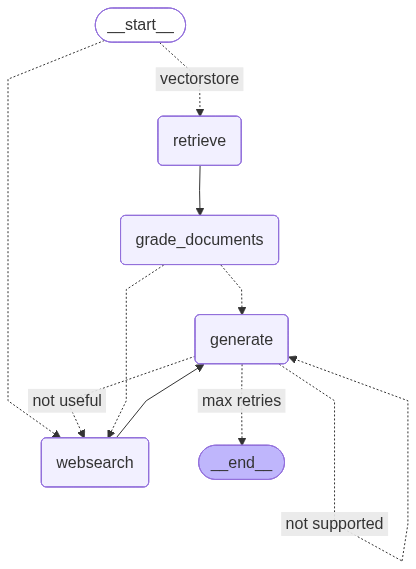

In [75]:
from langgraph.graph import StateGraph
from IPython.display import Image, display

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("websearch", web_search)  # web search
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate

# Build graph
workflow.set_conditional_entry_point(
    route_question,
    {
        "websearch": "websearch",
        "vectorstore": "retrieve",
    },
)
workflow.add_edge("websearch", "generate")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "websearch": "websearch",
        "generate": "generate",
    },
)
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "websearch",
        "max retries": END,
    },
)

# Compile
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [76]:
inputs = {"question": "What are the types of agent memory?", "max_retries": 3}
for event in graph.stream(inputs, stream_mode="values"):
    print(event)

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
{'question': 'What are the types of agent memory?', 'max_retries': 3, 'loop_step': 0}
---RETRIEVE---
{'question': 'What are the types of agent memory?', 'max_retries': 3, 'loop_step': 0, 'documents': [Document(metadata={'id': 'e92934b8-f5be-4e25-907c-adb52216f0be', 'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks

In [77]:
# Test on current events
inputs = {
    "question": "What are the models released today for llama3.2?",
    "max_retries": 3,
}
for event in graph.stream(inputs, stream_mode="values"):
    print(event)

---ROUTE QUESTION---
---ROUTE QUESTION TO WEB SEARCH---
{'question': 'What are the models released today for llama3.2?', 'max_retries': 3, 'loop_step': 0}
---WEB SEARCH---
{'question': 'What are the models released today for llama3.2?', 'max_retries': 3, 'loop_step': 0, 'documents': [Document(metadata={}, page_content="Ollama\n\n69.4M\n Downloads\n\nUpdated \n1 year ago\n\n## Meta's Llama 3.2 goes small with 1B and 3B models.\n\n## Applications\n\nClaude Code\n`ollama launch claude --model llama3.2`\nCodex App\n`ollama launch codex-app --model llama3.2`\nOpenClaw\n`ollama launch openclaw --model llama3.2`\nHermes Agent\n`ollama launch hermes --model llama3.2`\nCodex\n`ollama launch codex --model llama3.2`\nOpenCode\n`ollama launch opencode --model llama3.2`\n\n## Models\n\nName\n\n63 models\n\nSize / Usage\n\nContext\n\nInput\n\nllama3.2:latest\n\n2.0GB · 128K context window · Text · 1 year ago\n\n2.0GB\n\n128K\n\nText\n\nllama3.2:1b\n\n1.3GB · 128K context window · Text · 1 year ago\n